In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('data.csv')
df.head()

,Sum,Days,Color
0,22.072345,36.758307,1
1,37.936710,55.784810,1
2,21.083576,47.319176,1
3,31.120670,54.406780,1
4,43.711550,42.557729,1


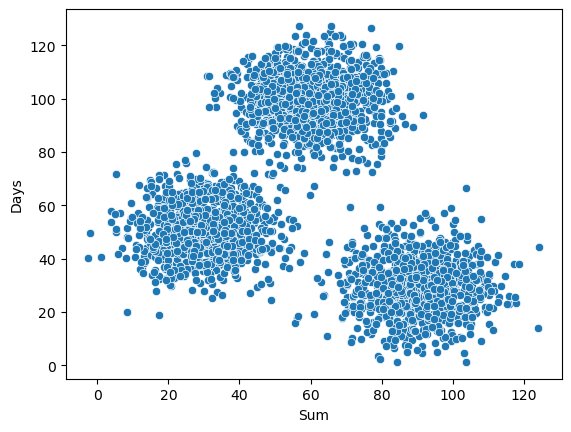

In [3]:
sns.scatterplot(x=df['Sum'], y=df['Days']);

In [4]:
data = df[['Sum', 'Days']]

n_clusters = list(range(2, 7))
metrics = []

for k in n_clusters:
  km = KMeans(n_clusters=k).fit(data)
  score = silhouette_score(data, km.labels_)
  metrics.append(score)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^

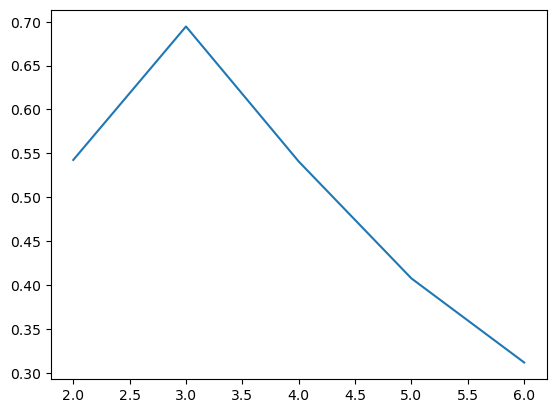

In [6]:
sns.lineplot(x=n_clusters, y=metrics);


In [7]:

print('\n' * 20)

# Видео 2

In [8]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [9]:
df = pd.read_csv('data.csv')
df.head()

,Sum,Days,Color
0,22.072345,36.758307,1
1,37.936710,55.784810,1
2,21.083576,47.319176,1
3,31.120670,54.406780,1
4,43.711550,42.557729,1


<Axes: xlabel='Sum', ylabel='Days'>

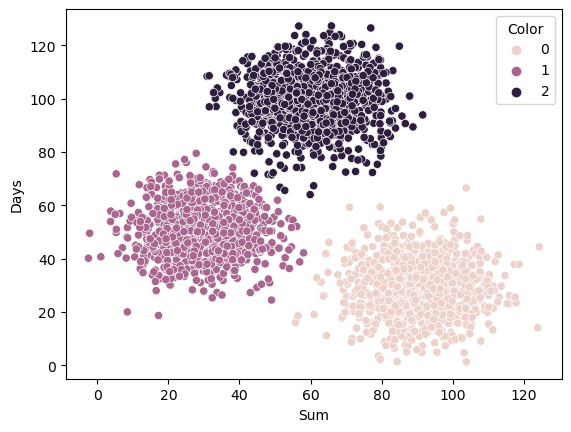

In [11]:
sns.scatterplot(x=df['Sum'], y=df['Days'], hue=df['Color'])

In [12]:
features = ['Sum', 'Days']

df_g = df.groupby('Color').agg({x: ['mean', 'std'] for x in features}).T
df_g

Color              0          1          2
Sum  mean  89.924184  29.311610  60.623093
     std   10.463459  10.052721  10.166339
Days mean  29.880359  50.541746  99.530350
     std   10.324979   9.704615   9.954158

In [13]:
import numpy as np

functions = ['mean', 'std']

stat = np.array([[df[feature].apply(f) for f in functions] for feature in features]).flatten()

df_g_rel = df_g.copy()
df_g_rel['Global'] = stat
df_g_rel

Color              0          1          2     Global
Sum  mean  89.924184  29.311610  60.623093  60.611358
     std   10.463459  10.052721  10.166339  25.859054
Days mean  29.880359  50.541746  99.530350  62.862141
     std   10.324979   9.704615   9.954158  31.759714

In [14]:
cluster_labels = [0, 1, 2]

for label in cluster_labels:
  df_g_rel[label] = 100 * df_g_rel[label] / df_g_rel['Global'] - 100

df_g_rel

Color              0          1          2     Global
Sum  mean  48.361935 -51.640071   0.019361  60.611358
     std  -59.536575 -61.124946 -60.685573  25.859054
Days mean -52.466845 -19.599070  58.331148  62.862141
     std  -67.490329 -69.443634 -68.657911  31.759714

<Axes: xlabel='Color', ylabel='None-None'>

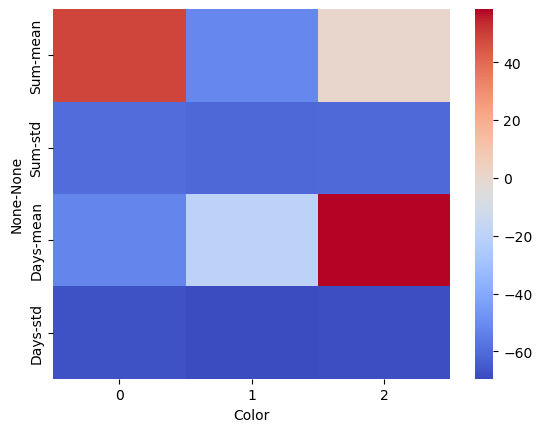

In [15]:
sns.heatmap(df_g_rel[cluster_labels], cmap='coolwarm')

# Видео 3

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv('st900.csv')
df.head()

In [ ]:
df.shape

In [ ]:
km = KMeans(n_clusters=4).fit(df)
labels = km.labels_

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=20)
df_emb = tsne.fit_transform(df)
data = pd.DataFrame(df_emb)
data

In [ ]:
sns.scatterplot(data[0], data[1], hue=labels)